In [1]:
import pip
!pip install pmdarima


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install tensorflow


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install keras_tuner


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install tensorboard


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# import libraries
from gettext import install
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pip
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.engine import get_metrics, create_lstm_sequence
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import pmdarima as pm
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
from sqlalchemy import values
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler

In [7]:
# load csv
df = pd.read_csv(r'../data/processed/cleaned_featured_data.csv', parse_dates=['observation_date'], index_col='observation_date')
df_clean = df.dropna()

In [8]:
# train test split
tscv = TimeSeriesSplit(n_splits=5)
train_size = int(len(df_clean) * 0.8)
train, test = df_clean.iloc[:train_size], df_clean.iloc[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}")
print(f"Testing shape: {test.shape}, Training shape: {train.shape}")

Train size: 1020, Test size: 255
Testing shape: (255, 13), Training shape: (1020, 13)


In [9]:
# SARIMA Model
print("Fitting SARIMA model...")
sarima_model = pm.auto_arima(train['DHHNGSP'], seasonal=True, m=7, suppress_warnings=True)

# Forecasting with SARIMA
sarima_preds, sarima_conf_int = sarima_model.predict(n_periods=len(test), return_conf_int=True)
sarima_metrics = get_metrics(test['DHHNGSP']. values, sarima_preds.values)
print(f"SARIMA Metrics: {sarima_metrics}")

Fitting SARIMA model...
SARIMA Metrics: {'MAE': 0.7988613546566415, 'RMSE': 2.51389782494208, 'MAPE': 16.141396118070293}


In [10]:
# Hyperparameter Tuning for SARIMA
print("Starting hyperparameter tuning for SARIMA...")
tuned_sarima_model = pm.auto_arima(
    train['DHHNGSP'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    m=7, start_P=0, start_Q=0,
    max_P=3, max_Q=3,
    seasonal=True,
    d=None, D=None,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    random_state=42,
    random=True,
    n_fits=15
)

print(f"Best SARIMA Model order: {tuned_sarima_model.order}")
print(f"Best SARIMA Model seasonal order: {tuned_sarima_model.seasonal_order}")

# evaluate the tuned SARIMA model
tuned_sarima_preds = tuned_sarima_model.predict(n_periods=len(test))
tuned_sarima_metrics = get_metrics(test['DHHNGSP'].values, tuned_sarima_preds.values)


print(f"Baseline SARIMA Metrics: {sarima_metrics}")
print(f"Tuned SARIMA Metrics: {tuned_sarima_metrics}")

Starting hyperparameter tuning for SARIMA...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=1639.374, Time=0.13 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1583.456, Time=0.24 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=1554.805, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=1637.375, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=1554.005, Time=0.12 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=1554.821, Time=0.29 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=1556.799, Time=0.77 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=1528.905, Time=0.36 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=1530.178, Time=0.65 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=1530.167, Time=0.72 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=1532.160, Time=1.34 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=1582.249, Time=0.19 sec
 ARIMA(2,1,1)(0,0,0)[7] intercept   : AIC=1530.652, Time=0.47 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=1530.564, Ti

In [11]:
# Random Forest Model
print("Fitting Random Forest model...")
features = ['lag_1', 'lag_2', 'lag_3', 'Rolling_Std_7']
X_train, y_train = train[features], train['DHHNGSP']
X_test, y_test = test[features], test['DHHNGSP']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Forecasting with Random Forest
rf_preds = rf_model.predict(X_test)
rf_metrics = get_metrics(y_test.values, rf_preds)
print(f"Random Forest Metrics: {rf_metrics}")

Fitting Random Forest model...
Random Forest Metrics: {'MAE': 0.4223030392156868, 'RMSE': 2.060897350072722, 'MAPE': 6.1882752539184995}


In [12]:
# Hyperparameter Tuning for RandomForest
print('Hyperparameter tuning for Random Forest via RandomizedSearchCV...')
rf_param_grid = {
    'n_estimators': [100, 200, 300,500],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

# base model
rf_base_model = RandomForestRegressor(random_state=42)

tscv = TimeSeriesSplit(n_splits=3)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base_model,
    param_distributions=rf_param_grid,
    n_iter=15,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
)

rf_random_search.fit(X_train, y_train)

print(f"Best Random Forest Parameters: {rf_random_search.best_params_}")
best_rf_model = rf_random_search.best_estimator_

# evaluate the tuned Random Forest model
best_rf_preds = best_rf_model.predict(X_test)
best_rf_metrics = get_metrics(y_test.values, best_rf_preds)

print(f"Baseline Random Forest Metrics: {rf_metrics}")
print(f"Tuned Random Forest Metrics: {best_rf_metrics}")

# forecasting with best Random Forest model
best_rf_preds = best_rf_model.predict(X_test)
cest_rf_metrics = get_metrics(y_test.values, best_rf_preds)
print(f"Best Random Forest Metrics: {best_rf_metrics}")

Hyperparameter tuning for Random Forest via RandomizedSearchCV...
Best Random Forest Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 15}
Baseline Random Forest Metrics: {'MAE': 0.4223030392156868, 'RMSE': 2.060897350072722, 'MAPE': 6.1882752539184995}
Tuned Random Forest Metrics: {'MAE': 0.3969996858922311, 'RMSE': 2.0091456411209045, 'MAPE': 5.745239931818722}
Best Random Forest Metrics: {'MAE': 0.3969996858922311, 'RMSE': 2.0091456411209045, 'MAPE': 5.745239931818722}


In [13]:
# XGBoost Model
print("Fitting XGBoost model...")
xgb_model = XGBRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Forecasting with XGBoost
xgb_preds = xgb_model.predict(X_test)
xgb_metrics = get_metrics(y_test.values, xgb_preds)
print(f"XGBoost Metrics: {xgb_metrics}")

Fitting XGBoost model...
XGBoost Metrics: {'MAE': 0.4386604853985356, 'RMSE': 2.165315962971091, 'MAPE': 6.272163738619395}


In [14]:
# Hyperparameter Tuning for XGBoost
print("Starting hyperparameter tuning for XGBoost via RandomizedSearchCV...")
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.5, 0.1]
}

xgb_base_model = XGBRegressor(random_state=42)
tscv = TimeSeriesSplit(n_splits=3)
random_search = RandomizedSearchCV(
    estimator=xgb_base_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

print(f"Best parameters found: {random_search.best_params_}")
best_xgb_model = random_search.best_estimator_

# evaluate the best model on the test set
best_xgb_test_preds = best_xgb_model.predict(X_test)
best_xgb_test_metrics = get_metrics(y_test.values, best_xgb_test_preds)
print(f"Best XGBoost Test Metrics: {best_xgb_test_metrics}")


Starting hyperparameter tuning for XGBoost via RandomizedSearchCV...
Best parameters found: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.5}
Best XGBoost Test Metrics: {'MAE': 0.44224349380941946, 'RMSE': 2.071611045817551, 'MAPE': 6.914142411187278}


In [15]:
# LSTM Model
print("Fitting LSTM model...")
time_steps = 30
scaler = MinMaxScaler()
target_series_raw = df_clean['DHHNGSP'].values.reshape(-1, 1)
target_series_scaled = scaler.fit_transform(target_series_raw).flatten()

X_lstm, y_lstm = create_lstm_sequence(target_series_scaled, time_steps)

# Choronological split for LSTM
lstm_train_size = int(len(X_lstm) * 0.8)
X_lstm_train, X_lstm_test = X_lstm[:lstm_train_size], X_lstm[lstm_train_size:]
y_lstm_train, y_lstm_test = y_lstm[:lstm_train_size], y_lstm[lstm_train_size:]

# Reshape X to (samples, time_steps, features)
X_lstm_train = X_lstm_train.reshape((X_lstm_train.shape[0], X_lstm_train.shape[1], 1))
X_lstm_test = X_lstm_test.reshape((X_lstm_test.shape[0], X_lstm_test.shape[1], 1))

# Build LSTM model
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(time_steps, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

# fIT the model
lstm_model.fit(X_lstm_train, y_lstm_train, epochs=20, batch_size=32, verbose=1)

y_lstm_test_actual = scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).flatten()


# Forecasting with LSTM
lstm_preds_scaled = lstm_model.predict(X_lstm_test, verbose=0).flatten()
lstm_preds = scaler.inverse_transform(lstm_preds_scaled.reshape(-1, 1)).flatten()
lstm_metrics = get_metrics(y_lstm_test_actual, lstm_preds)
print(f"LSTM Metrics: {lstm_metrics}")

Fitting LSTM model...
Epoch 1/20


c:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0048
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.7920e-04
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.4985e-04
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.1819e-04
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9116e-04
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.9209e-04
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9204e-04
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8100e-04
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.6969e-04
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.5970e-04
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.5821e-04
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4477e-04
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.3885e-04
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/s

In [16]:
# Hyperparameter Tuning for LSTM
print("Starting hyperparameter tuning for LSTM via Keras Tuner...")
def build_lstm_model(hp):
    model = Sequential()
    
    hp_units = hp.Int('units', min_value=32, max_value=128, step=32)
    
    hp_activation = hp.Choice('activation', values=['relu', 'tanh'])
    
    model.add(LSTM(units=hp_units, activation=hp_activation, input_shape=(time_steps, 1)))
    model.add(Dense(1))
    
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=hp_learning_rate), loss='mse')
    return model

val_split = int(len(X_lstm_train) * 0.8)
X_tune_train, X_tune_val = X_lstm_train[:val_split], X_lstm_train[val_split:]
y_tune_train, y_tune_val = y_lstm_train[:val_split], y_lstm_train[val_split:]

tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_loss', 
    max_trials=10,             
    executions_per_trial=1,    
    directory='tuning_dir',    
    project_name='lstm_ng_gas',
    seed=42,
    overwrite=True # Good practice in Jupyter to clear previous failed runs
)

# Execute the hyperparameter search
print("Starting hyperparameter search for LSTM...")
tuner.search(
    x=X_tune_train, 
    y=y_tune_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_tune_val, y_tune_val),
    shuffle=False,
    verbose=1 
)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters: Units: {best_hps.get('units')}, Activation: {best_hps.get('activation')}, Learning Rate: {best_hps.get('learning_rate')}")

# Build and train the final tuned model on the full training set
best_lstm_model = build_lstm_model(best_hps)
best_lstm_model.fit(X_lstm_train, y_lstm_train, epochs=30, batch_size=32, verbose=0,shuffle=False)

# Evaluate the tuned LSTM model on the test set
tuned_lstm_preds_scaled = best_lstm_model.predict(X_lstm_test, verbose=0).flatten()
tuned_lstm_preds = scaler.inverse_transform(tuned_lstm_preds_scaled.reshape(-1, 1)).flatten()
tuned_lstm_metrics = get_metrics(y_lstm_test_actual, tuned_lstm_preds)


print(f"Tuned LSTM Metrics: {tuned_lstm_metrics}")
print(f"Baseline LSTM Metrics: {lstm_metrics}")


Trial 10 Complete [00h 00m 11s]
val_loss: 0.000670336652547121

Best val_loss So Far: 0.00036230089608579874
Total elapsed time: 00h 01m 51s
Best hyperparameters: Units: 96, Activation: tanh, Learning Rate: 0.01
Tuned LSTM Metrics: {'MAE': 0.39625953473623504, 'RMSE': 1.8430451850380472, 'MAPE': 6.092601176651393}
Baseline LSTM Metrics: {'MAE': 0.5275742480266525, 'RMSE': 2.1657688049302943, 'MAPE': 9.087851077080106}


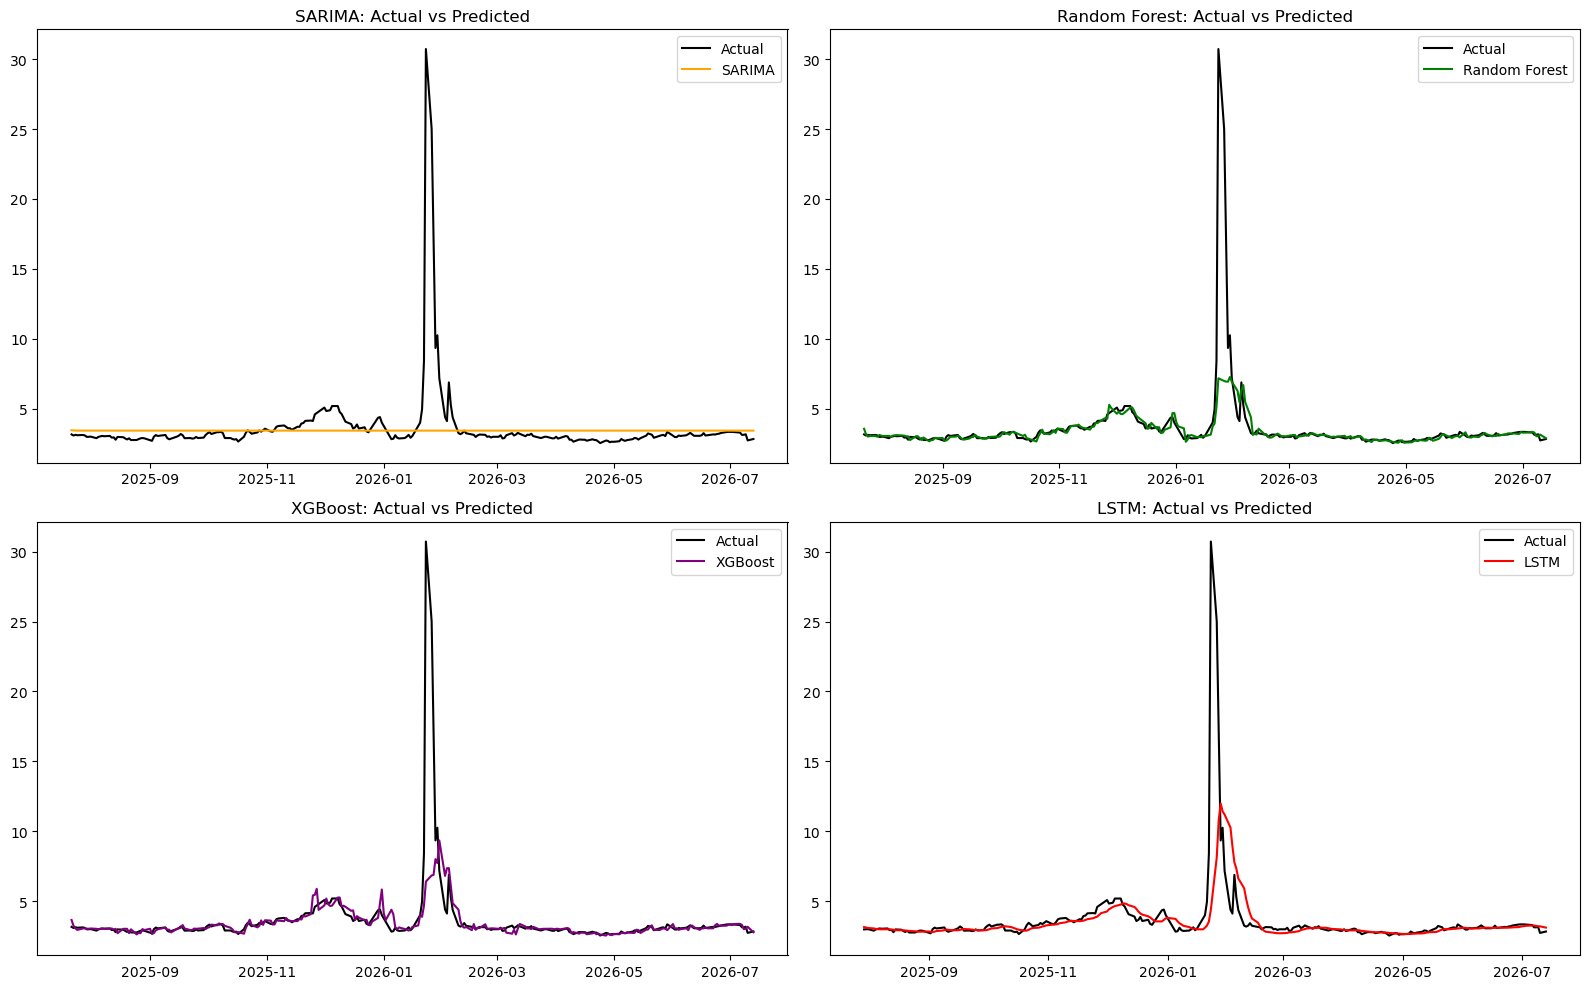

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(test.index, test['DHHNGSP'].values, label='Actual', color='black')
axes[0,0].plot(test.index, tuned_sarima_preds.values, label='SARIMA', color='orange')
axes[0,0].set_title('SARIMA: Actual vs Predicted')
axes[0,0].legend()

axes[0,1].plot(test.index, y_test.values, label='Actual', color='black')
axes[0,1].plot(test.index, best_rf_preds, label='Random Forest', color='green')
axes[0,1].set_title('Random Forest: Actual vs Predicted')
axes[0,1].legend()

axes[1,0].plot(test.index, y_test.values, label='Actual', color='black')
axes[1,0].plot(test.index, best_xgb_test_preds, label='XGBoost', color='purple')
axes[1,0].set_title('XGBoost: Actual vs Predicted')
axes[1,0].legend()

test_dates_lstm = df_clean.index[-len(y_lstm_test_actual):]
axes[1,1].plot(test_dates_lstm, y_lstm_test_actual, label='Actual', color='black')
axes[1,1].plot(test_dates_lstm, lstm_preds, label='LSTM', color='red')
axes[1,1].set_title('LSTM: Actual vs Predicted')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('model_comparison_plots.png', dpi=150)
plt.show()

In [18]:
import json

# Consolidate metrics into a dictionary
point_forecast_metrics = {
    'SARIMA (Tuned)': tuned_sarima_metrics,
    'Random Forest (Tuned)': best_rf_metrics,
    'XGBoost (Tuned)': best_xgb_test_metrics,
    'LSTM (Tuned)': tuned_lstm_metrics
}

# Save to disk
with open('point_metrics.json', 'w') as f:
    json.dump(point_forecast_metrics, f)
print("Saved point forecast metrics to point_metrics.json")

Saved point forecast metrics to point_metrics.json
